<a href="https://colab.research.google.com/github/nachocabra/tesis-biomecanica-caballos/blob/main/tesis_pipeline_pose_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline de pose estimation — Tesis
Extracción de métricas biomecánicas de caballos de carrera a partir de
video de transmisión pública, mediante el modelo preentrenado
SuperAnimal-Quadruped (DeepLabCut).

## 1. Instalación de DeepLabCut

Instalamos la librería DeepLabCut, incluyendo el extra `modelzoo`, que da
acceso a los modelos preentrenados (entre ellos, SuperAnimal-Quadruped,
el que usamos en este trabajo) sin necesidad de entrenar uno propio.

In [ ]:
!pip install deeplabcut[gui,modelzoo]

## 2. Conexión con Google Drive

Montamos Google Drive dentro de la sesión de Colab, para que los videos
y los resultados generados queden guardados de forma permanente, en
lugar de perderse cuando se corte la sesión.

## 3. Estructura de carpetas y rutas de trabajo

Definimos la organización de carpetas dentro de Drive:

- `videos_originales/`: los videos completos, descargados con yt-dlp.
- `clips/`: recortes cortos de tramos específicos, usados para las pruebas.
- `resultados/`: salidas del modelo (coordenadas, video con keypoints
  dibujados), separadas en una subcarpeta por cada prueba realizada.

También definimos variables con las rutas a los videos originales, para
no repetir las rutas completas en cada celda.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/Tesis/videos', exist_ok=True)

In [ ]:
import os
os.listdir('/content/drive/MyDrive/Tesis/videos')

['Gulfstream Park September 20, 2026 Race 9.mp4',
 '2026 Jockey Club Gold Cup- Forever Young.webm']

---
# Pruebas exploratorias de pose estimation

Primeras corridas del modelo sobre clips cortos, para verificar
viabilidad técnica antes de definir el pipeline completo.

In [ ]:
video_gulfstream = '/content/drive/MyDrive/Tesis/videos/Gulfstream Park September 20, 2026 Race 9.mp4'
video_belmont = '/content/drive/MyDrive/Tesis/videos/2026 Jockey Club Gold Cup- Forever Young.webm'

## 4. Prueba 1: recorte de Gulfstream Park

Cortamos un clip de 10 segundos del video de Gulfstream Park, a partir
del minuto 1:49, correspondiente al tramo identificado como lateral
limpio (sin obstrucción de la valla), según el relevamiento manual de
ángulos de cámara hecho previamente.

In [ ]:
!ffmpeg -i "{video_gulfstream}" -ss 00:01:49 -t 10 -c copy /content/drive/MyDrive/Tesis/videos/gulfstream_clip.mp4


ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

## 5. Prueba 1: primera corrida del modelo (SuperAnimal-Quadruped)

Corremos el modelo de pose estimation preentrenado sobre el clip de
Gulfstream, para verificar si el pipeline funciona técnicamente sobre
video de carrera real.

Nota: en esta corrida, el parámetro `video_adapt=True` (que reduce el
parpadeo/jitter de las predicciones mediante un reentrenamiento breve)
causó un error de memoria de GPU (`CUDA out of memory`) en la etapa de
ajuste. El análisis principal, sin embargo, se completó correctamente
antes de ese punto, generando resultados válidos.

In [ ]:
import deeplabcut

clip_path = '/content/drive/MyDrive/Tesis/videos/gulfstream_clip.mp4'

deeplabcut.video_inference_superanimal(
    [clip_path],
    "superanimal_quadruped",
    model_name="hrnet_w32",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    scale_list=range(200, 1000, 100),
    video_adapt=True
)

Running video inference on ['/content/drive/MyDrive/Tesis/videos/gulfstream_clip.mp4'] with superanimal_quadruped_hrnet_w32
Using pytorch for model hrnet_w32
Loading.... superanimal_quadruped_hrnet_w32


/usr/local/lib/python3.13/dist-packages/deeplabcut/pose_estimation_pytorch/config/data.py:139: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  build_transforms(v)


superanimal_quadruped_hrnet_w32.pt: reconstructing file:   0%|          |  0.00B /  118MB            

superanimal_quadruped_hrnet_w32.pt: downloading bytes:           |  0.00B            

Loading.... superanimal_quadruped_fasterrcnn_resnet50_fpn_v2


...

Saving results to /content/drive/MyDrive/Tesis/videos
Saving results in /content/drive/MyDrive/Tesis/videos/gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2.h5 and /content/drive/MyDrive/Tesis/videos/gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_full.pickle
Duration of video [s]: 9.74, recorded with 29.97 fps!
Overall # of frames: 292 with cropped frame dimensions: 1920 1080
Generating frames and creating video.


100%|██████████| 271/271 [00:11<00:00, 23.83it/s]


Video with predictions was saved as /content/drive/MyDrive/Tesis/videos/gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_labeled_before_adapt.mp4
Video frames being extracted to /content/drive/MyDrive/Tesis/videos/pseudo_gulfstream_clip/images for video adaptation.
Constructing pseudo dataset at /content/drive/MyDrive/Tesis/videos/pseudo_gulfstream_clip
Truncated both arrays to length 271
Running video adaptation with following parameters:
  video adaptation batch size: 8
  (pose training) pose_epochs: 4
  (pose) save_epochs: 1
  detector_epochs: 4
  detector_save_epochs: 1



/usr/local/lib/python3.13/dist-packages/deeplabcut/pose_estimation_pytorch/config/data.py:139: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  build_transforms(v)
/usr/local/lib/python3.13/dist-packages/deeplabcut/pose_estimation_pytorch/apis/training.py:137: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  transform = build_transforms(run_config["data"]["train"])
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.

OutOfMemoryError: CUDA out of memory. Tried to allocate 126.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 121.81 MiB is free. Including non-PyTorch memory, this process has 14.44 GiB memory in use. Of the allocated memory 14.13 GiB is allocated by PyTorch, and 189.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 6. Reorganización de carpetas

Reorganizamos los archivos generados hasta este punto (que habían
quedado todos en una única carpeta) en la estructura definitiva descrita
en el paso 3, y eliminamos archivos intermedios sin uso (generados por
el intento fallido de ajuste del paso anterior).

In [ ]:
import os
import shutil

base = '/content/drive/MyDrive/Tesis'

# Creamos las carpetas nuevas
os.makedirs(f'{base}/videos_originales', exist_ok=True)
os.makedirs(f'{base}/clips', exist_ok=True)
os.makedirs(f'{base}/resultados', exist_ok=True)

# Movemos los videos originales
shutil.move(f'{base}/videos/2026 Jockey Club Gold Cup- Forever Young.webm', f'{base}/videos_originales/')
shutil.move(f'{base}/videos/Gulfstream Park September 20, 2026 Race 9.mp4', f'{base}/videos_originales/')

# Movemos el clip
shutil.move(f'{base}/videos/gulfstream_clip.mp4', f'{base}/clips/')

# Movemos los resultados del modelo (todo lo que empieza con "gulfstream_clip_superanimal")
for archivo in os.listdir(f'{base}/videos'):
    if archivo.startswith('gulfstream_clip_superanimal'):
        shutil.move(f'{base}/videos/{archivo}', f'{base}/resultados/')

# Borramos la carpeta basura del intento fallido
shutil.rmtree(f'{base}/videos/pseudo_gulfstream_clip')

# Confirmamos que la carpeta "videos" vieja quedó vacía, y la borramos
os.rmdir(f'{base}/videos')

Error: Destination path '/content/drive/MyDrive/Tesis/videos_originales/2026 Jockey Club Gold Cup- Forever Young.webm' already exists

## 7. Actualización de rutas

Actualizamos las variables de rutas para que apunten a la nueva
estructura de carpetas.

In [ ]:
print("En videos_originales:", os.listdir(f'{base}/videos_originales'))
print("En videos:", os.listdir(f'{base}/videos'))

En videos_originales: ['Gulfstream Park September 20, 2026 Race 9.mp4', '2026 Jockey Club Gold Cup- Forever Young.webm']


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Tesis/videos'

In [ ]:
print("Tesis (raíz):", os.listdir(base))
print()
print("clips:", os.listdir(f'{base}/clips'))
print()
print("resultados:", os.listdir(f'{base}/resultados'))

Tesis (raíz): ['videos_originales', 'clips', 'resultados']

clips: ['gulfstream_clip.mp4', 'belmont_clip.mp4', 'belmont_clip_h264.mp4']

resultados: ['gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2.h5', 'gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_before_adapt.json', 'gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_labeled_before_adapt.mp4']


In [ ]:
video_gulfstream = f'{base}/videos_originales/Gulfstream Park September 20, 2026 Race 9.mp4'
video_belmont = f'{base}/videos_originales/2026 Jockey Club Gold Cup- Forever Young.webm'
clip_path = f'{base}/clips/gulfstream_clip.mp4'

In [ ]:
os.listdir(f'{base}/videos_originales')

['Gulfstream Park September 20, 2026 Race 9.mp4',
 '2026 Jockey Club Gold Cup- Forever Young.webm']

## 8. Prueba 2: recorte de Belmont Park

Cortamos un clip de 6 segundos del video de Belmont Park (transmitido
por ESPN), a partir del minuto 2:08, correspondiente al tramo lateral
limpio identificado en el relevamiento manual.

In [ ]:
!ffmpeg -i "{video_belmont}" -ss 00:02:08 -t 6 -c copy {base}/clips/belmont_clip.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

## 9. Prueba 2: primer intento fallido — incompatibilidad de códec

Al intentar correr el modelo sobre este clip, el análisis procesó 0 de
176 cuadros. La causa identificada fue que el video de origen está
codificado en AV1, un códec que la herramienta de lectura de video usada
internamente por DeepLabCut no logra decodificar correctamente, a
diferencia de H.264 (usado en el clip de Gulfstream, que sí funcionó sin
problemas).

In [ ]:
deeplabcut.video_inference_superanimal(
    [f'{base}/clips/belmont_clip.mp4'],
    "superanimal_quadruped",
    model_name="hrnet_w32",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    scale_list=range(200, 1000, 100),
    video_adapt=False
)

Found invalid empty/null/None value for `Task` in the project config. This is only supported for legacy compatibility. Treating `Task` as unset and using the field default instead.
Found invalid empty/null/None value for `scorer` in the project config. This is only supported for legacy compatibility. Treating `scorer` as unset and using the field default instead.
Found invalid empty/null/None value for `date` in the project config. This is only supported for legacy compatibility. Treating `date` as unset and using the field default instead.
Found invalid empty/null/None value for `multianimalproject` in the project config. This is only supported for legacy compatibility. Treating `multianimalproject` as unset and using the field default instead.
Found invalid empty/null/None value for `project_path` in the project config. This is only supported for legacy compatibility. Treating `project_path` as unset and using the field default instead.
Found invalid empty/null/None value for `video_

Running video inference on ['/content/drive/MyDrive/Tesis/clips/belmont_clip.mp4'] with superanimal_quadruped_hrnet_w32
Using pytorch for model hrnet_w32
Processing video /content/drive/MyDrive/Tesis/clips/belmont_clip.mp4
Starting to analyze /content/drive/MyDrive/Tesis/clips/belmont_clip.mp4
Video metadata: 
  Overall # of frames:    176
  Duration of video [s]:  5.87
  fps:                    29.97
  resolution:             w=1280, h=720

Running detector with batch size 1


  0%|          | 0/176 [00:00<?, ?it/s]


Running pose prediction with batch size 1


  0%|          | 0/176 [00:00<?, ?it/s]
The video metadata indicates that there 176 in the video, but only 0 were able to be processed. This can happen if the video is corrupted. You can try to fix the issue by re-encoding your video (tips on how to do that: https://deeplabcut.github.io/DeepLabCut/docs/recipes/io.html#tips-on-video-re-encoding-and-preprocessing)


RuntimeError: No pose predictions were made for video /content/drive/MyDrive/Tesis/clips/belmont_clip.mp4. Were no individuals detected?

## 10. Prueba 2: re-codificación a H.264

Convertimos el clip de Belmont del códec AV1 a H.264, para resolver la
incompatibilidad detectada en el paso anterior.


In [ ]:
!ffmpeg -i "{base}/clips/belmont_clip.mp4" -c:v libx264 -c:a aac {base}/clips/belmont_clip_h264.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

## 11. Prueba 2: corrida del modelo sobre el clip corregido

Corremos el modelo sobre el clip de Belmont ya convertido a H.264,
guardando los resultados en una subcarpeta separada de los de la Prueba 1,
para no mezclar los resultados de ambos hipódromos.

In [ ]:
!ffmpeg -i "{base}/clips/belmont_clip.mp4" -c:v libx264 -c:a aac {base}/clips/belmont_clip_h264.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [ ]:

import deeplabcut

In [ ]:
import os

os.makedirs(f'{base}/resultados/prueba2_belmont', exist_ok=True)

deeplabcut.video_inference_superanimal(
    [f'{base}/clips/belmont_clip_h264.mp4'],
    "superanimal_quadruped",
    model_name="hrnet_w32",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    scale_list=range(200, 1000, 100),
    video_adapt=False,
    dest_folder=f'{base}/resultados/prueba2_belmont'
)

Running video inference on ['/content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4'] with superanimal_quadruped_hrnet_w32
Using pytorch for model hrnet_w32


/usr/local/lib/python3.13/dist-packages/deeplabcut/pose_estimation_pytorch/config/data.py:139: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  build_transforms(v)


Processing video /content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4
Starting to analyze /content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4
Video metadata: 
  Overall # of frames:    180
  Duration of video [s]:  6.01
  fps:                    29.97
  resolution:             w=1280, h=720

Running detector with batch size 1


100%|██████████| 180/180 [00:29<00:00,  6.04it/s]


Running pose prediction with batch size 1


100%|██████████| 180/180 [00:11<00:00, 15.86it/s]


Saving results to /content/drive/MyDrive/Tesis/resultados/prueba2_belmont
Saving results in /content/drive/MyDrive/Tesis/resultados/prueba2_belmont/belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2.h5 and /content/drive/MyDrive/Tesis/resultados/prueba2_belmont/belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_full.pickle
Duration of video [s]: 6.01, recorded with 29.97 fps!
Overall # of frames: 180 with cropped frame dimensions: 1280 720
Generating frames and creating video.


100%|██████████| 180/180 [00:03<00:00, 47.26it/s]

Video with predictions was saved as /content/drive/MyDrive/Tesis/resultados/prueba2_belmont/belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_labeled_before_adapt.mp4


{'/content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4': scorer      superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2  \
 individuals                                                    animal0   
 bodyparts                                                         nose   
 coords                                                               x   
 0                                                   655.882812           
 1                                                   655.882812           
 2                                                   655.882812           
 3                                                   655.882812           
 4                                                   655.882812           
 ..                                                         ...           
 175                                                 896.960938           
 176                                                 772.054688           
 177                                    

In [1]:
os.makedirs(f'{base}/resultados/prueba4_belmont_adapt', exist_ok=True)

deeplabcut.video_inference_superanimal(
    [f'{base}/clips/belmont_clip_h264.mp4'],
    "superanimal_quadruped",
    model_name="hrnet_w32",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    scale_list=range(200, 1000, 100),
    video_adapt=True,
    batch_size=2,
    dest_folder=f'{base}/resultados/prueba4_belmont_adapt'
)

NameError: name 'os' is not defined

---
# Sesión 2 — [fecha de hoy]

Nueva sesión de Colab (la anterior se cerró). Se reinstala DeepLabCut
y se vuelve a montar Drive, ya que las variables y librerías cargadas
en memoria no persisten entre sesiones.

In [1]:
!pip install deeplabcut[gui,modelzoo]

In [2]:
import os
import shutil
import deeplabcut

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
base = '/content/drive/MyDrive/Tesis'
video_gulfstream = f'{base}/videos_originales/Gulfstream Park September 20, 2026 Race 9.mp4'
video_belmont = f'{base}/videos_originales/2026 Jockey Club Gold Cup- Forever Young.webm'

### Intento fallido: parámetro incorrecto

Se intentó `batch_size=2`, pensando que reduciría la memoria usada por
el reentrenamiento del adapt. Falló con el mismo error de memoria que
la Prueba 1 original, con un uso de GPU casi idéntico, lo que reveló
que ese no era el parámetro correcto (ver corrección en la celda
siguiente).

In [8]:
os.makedirs(f'{base}/resultados/prueba4_belmont_adapt', exist_ok=True)

deeplabcut.video_inference_superanimal(
    [f'{base}/clips/belmont_clip_h264.mp4'],
    "superanimal_quadruped",
    model_name="hrnet_w32",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    scale_list=range(200, 1000, 100),
    video_adapt=True,
    batch_size=2,
    dest_folder=f'{base}/resultados/prueba4_belmont_adapt'
)

Running video inference on ['/content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4'] with superanimal_quadruped_hrnet_w32
Using pytorch for model hrnet_w32


/usr/local/lib/python3.13/dist-packages/deeplabcut/pose_estimation_pytorch/config/data.py:139: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  build_transforms(v)


Loading.... superanimal_quadruped_hrnet_w32


superanimal_quadruped_hrnet_w32.pt: reconstructing file:   0%|          |  0.00B /  118MB            

superanimal_quadruped_hrnet_w32.pt: downloading bytes:           |  0.00B            

...

Saving results to /content/drive/MyDrive/Tesis/resultados/prueba4_belmont_adapt
Saving results in /content/drive/MyDrive/Tesis/resultados/prueba4_belmont_adapt/belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2.h5 and /content/drive/MyDrive/Tesis/resultados/prueba4_belmont_adapt/belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_full.pickle
Duration of video [s]: 6.01, recorded with 29.97 fps!
Overall # of frames: 180 with cropped frame dimensions: 1280 720
Generating frames and creating video.


100%|██████████| 180/180 [00:03<00:00, 54.24it/s]


Video with predictions was saved as /content/drive/MyDrive/Tesis/resultados/prueba4_belmont_adapt/belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_labeled_before_adapt.mp4
Video frames being extracted to /content/drive/MyDrive/Tesis/clips/pseudo_belmont_clip_h264/images for video adaptation.
Constructing pseudo dataset at /content/drive/MyDrive/Tesis/clips/pseudo_belmont_clip_h264
Running video adaptation with following parameters:
  video adaptation batch size: 8
  (pose training) pose_epochs: 4
  (pose) save_epochs: 1
  detector_epochs: 4
  detector_save_epochs: 1



/usr/local/lib/python3.13/dist-packages/deeplabcut/pose_estimation_pytorch/config/data.py:139: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  build_transforms(v)
/usr/local/lib/python3.13/dist-packages/deeplabcut/pose_estimation_pytorch/apis/training.py:137: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  transform = build_transforms(run_config["data"]["train"])
Data Transforms:
  Training:   Compose([
  HorizontalFlip(always_apply=False, p=0.5),
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (1.0, 1.0), 'y': (1.0, 1.0)}, translate_percent=None, translate_px={'x': (-40, 40), 'y': (-40, 40)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  Normalize(always_apply=False, p=1.0, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.

OutOfMemoryError: CUDA out of memory. Tried to allocate 126.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 105.81 MiB is free. Including non-PyTorch memory, this process has 14.46 GiB memory in use. Of the allocated memory 14.19 GiB is allocated by PyTorch, and 144.83 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 12. Prueba 4: video adaptation sobre Belmont

Reintentamos el ajuste de "video adaptation" (que reduce el parpadeo/jitter
de las predicciones mediante un reentrenamiento breve y autosupervisado),
esta vez sobre el clip de Belmont.

**Error inicial**: el primer intento usó el parámetro `batch_size=2`,
asumiendo que controlaba el tamaño de lote del reentrenamiento del adapt.
Volvió a fallar con `CUDA out of memory`, con un uso de memoria casi
idéntico al error original. Esto reveló que `batch_size` controla la
etapa de análisis normal (que de por sí ya corre

In [5]:
os.makedirs(f'{base}/resultados/prueba4_belmont_adapt', exist_ok=True)

deeplabcut.video_inference_superanimal(
    [f'{base}/clips/belmont_clip_h264.mp4'],
    "superanimal_quadruped",
    model_name="hrnet_w32",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    scale_list=range(200, 1000, 100),
    video_adapt=True,
    video_adapt_batch_size=2,
    dest_folder=f'{base}/resultados/prueba4_belmont_adapt'
)

Running video inference on ['/content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4'] with superanimal_quadruped_hrnet_w32
Using pytorch for model hrnet_w32
Using /content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4 for video adaptation training


/usr/local/lib/python3.13/dist-packages/deeplabcut/pose_estimation_pytorch/config/data.py:139: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  build_transforms(v)


Processing video /content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4
Starting to analyze /content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4
Video metadata: 
  Overall # of frames:    180
  Duration of video [s]:  6.01
  fps:                    29.97
  resolution:             w=1280, h=720

Running detector with batch size 1


100%|██████████| 180/180 [00:32<00:00,  5.58it/s]


Running pose prediction with batch size 1


...

100%|██████████| 180/180 [00:15<00:00, 11.35it/s]


Saving results to /content/drive/MyDrive/Tesis/resultados/prueba4_belmont_adapt
Saving results in /content/drive/MyDrive/Tesis/resultados/prueba4_belmont_adapt/belmont_clip_h264_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004.h5 and /content/drive/MyDrive/Tesis/resultados/prueba4_belmont_adapt/belmont_clip_h264_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004_full.pickle
Duration of video [s]: 6.01, recorded with 29.97 fps!
Overall # of frames: 180 with cropped frame dimensions: 1280 720
Generating frames and creating video.


100%|██████████| 180/180 [00:06<00:00, 28.45it/s]


Video with predictions was saved as /content/drive/MyDrive/Tesis/resultados/prueba4_belmont_adapt/belmont_clip_h264_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004_labeled_after_adapt.mp4


{'/content/drive/MyDrive/Tesis/clips/belmont_clip_h264.mp4': scorer      superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004  \
 individuals                                                                              animal0   
 bodyparts                                                                                   nose   
 coords                                                                                         x   
 0                                                   387.734375                                     
 1                                                   387.664062                                     
 2                                                   387.734375                                     
 3                                                   387.664062                                     
 4                                                   387.734375                                     
 ..                            

In [6]:
os.makedirs(f'{base}/resultados/prueba3_gulfstream_adapt', exist_ok=True)

deeplabcut.video_inference_superanimal(
    [f'{base}/clips/gulfstream_clip.mp4'],
    "superanimal_quadruped",
    model_name="hrnet_w32",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    scale_list=range(200, 1000, 100),
    video_adapt=True,
    video_adapt_batch_size=2,
    dest_folder=f'{base}/resultados/prueba3_gulfstream_adapt'
)

Found invalid empty/null/None value for `Task` in the project config. This is only supported for legacy compatibility. Treating `Task` as unset and using the field default instead.
Found invalid empty/null/None value for `scorer` in the project config. This is only supported for legacy compatibility. Treating `scorer` as unset and using the field default instead.
Found invalid empty/null/None value for `date` in the project config. This is only supported for legacy compatibility. Treating `date` as unset and using the field default instead.
Found invalid empty/null/None value for `multianimalproject` in the project config. This is only supported for legacy compatibility. Treating `multianimalproject` as unset and using the field default instead.
Found invalid empty/null/None value for `project_path` in the project config. This is only supported for legacy compatibility. Treating `project_path` as unset and using the field default instead.
Found invalid empty/null/None value for `video_

Running video inference on ['/content/drive/MyDrive/Tesis/clips/gulfstream_clip.mp4'] with superanimal_quadruped_hrnet_w32
Using pytorch for model hrnet_w32
Using /content/drive/MyDrive/Tesis/clips/gulfstream_clip.mp4 for video adaptation training


/usr/local/lib/python3.13/dist-packages/deeplabcut/pose_estimation_pytorch/config/data.py:139: UserWarning: Be careful! Do not train pose models with horizontal flips if you have symmetric keypoints!
  build_transforms(v)


Processing video /content/drive/MyDrive/Tesis/clips/gulfstream_clip.mp4
Starting to analyze /content/drive/MyDrive/Tesis/clips/gulfstream_clip.mp4
Video metadata: 
  Overall # of frames:    292
  Duration of video [s]:  9.74
  fps:                    29.97
  resolution:             w=1920, h=1080

Running detector with batch size 1


100%|██████████| 292/292 [00:52<00:00,  5.53it/s]


...

100%|██████████| 292/292 [00:23<00:00, 12.21it/s]
The video metadata indicates that there 292 in the video, but only 275 were able to be processed. This can happen if the video is corrupted. You can try to fix the issue by re-encoding your video (tips on how to do that: https://deeplabcut.github.io/DeepLabCut/docs/recipes/io.html#tips-on-video-re-encoding-and-preprocessing)


Saving results to /content/drive/MyDrive/Tesis/resultados/prueba3_gulfstream_adapt
Saving results in /content/drive/MyDrive/Tesis/resultados/prueba3_gulfstream_adapt/gulfstream_clip_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004.h5 and /content/drive/MyDrive/Tesis/resultados/prueba3_gulfstream_adapt/gulfstream_clip_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004_full.pickle
Duration of video [s]: 9.74, recorded with 29.97 fps!
Overall # of frames: 292 with cropped frame dimensions: 1920 1080
Generating frames and creating video.


100%|██████████| 275/275 [00:12<00:00, 22.55it/s]

Video with predictions was saved as /content/drive/MyDrive/Tesis/resultados/prueba3_gulfstream_adapt/gulfstream_clip_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004_labeled_after_adapt.mp4


{'/content/drive/MyDrive/Tesis/clips/gulfstream_clip.mp4': scorer      superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004  \
 individuals                                                                              animal0   
 bodyparts                                                                                   nose   
 coords                                                                                         x   
 0                                                   439.265625                                     
 1                                                   606.867188                                     
 2                                                  1218.906250                                     
 3                                                  1238.195312                                     
 4                                                   607.851562                                     
 ..                              

In [7]:
before = f'{base}/resultados/prueba3_gulfstream_adapt/gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_labeled_before_adapt.mp4'
after = f'{base}/resultados/prueba3_gulfstream_adapt/gulfstream_clip_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004_labeled_after_adapt.mp4'

!ffmpeg -i "{before}" -i "{after}" -filter_complex hstack {base}/comparacion_gulfstream_adapt.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [8]:
print("Gulfstream adapt:", os.listdir(f'{base}/resultados/prueba3_gulfstream_adapt'))
print()
print("Belmont adapt:", os.listdir(f'{base}/resultados/prueba4_belmont_adapt'))

Gulfstream adapt: ['gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2.h5', 'gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_before_adapt.json', 'gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_labeled_before_adapt.mp4', 'gulfstream_clip_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004.h5', 'gulfstream_clip_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004_after_adapt.json', 'gulfstream_clip_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004_labeled_after_adapt.mp4']

Belmont adapt: ['belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2.h5', 'belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_before_adapt.json', 'belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2_labeled_before_adapt.mp4', 'belmont_clip_h264_superanimal_quadruped_s

## 13. Cuantificación del jitter: porcentaje de keypoints bien detectados

Hasta ahora, la comparación entre corridas con y sin `video_adapt` fue
visual. Para tener un dato objetivo, se calculó, para cada clip, el
porcentaje de cuadros en los que cada keypoint de `animal0` (el caballo
principal detectado) supera un umbral de confianza (`likelihood > 0.6`),
promediado entre los 39 keypoints.

Se usa `animal0` específicamente porque el clip contiene varios
caballos, y el número asignado a cada individuo no está garantizado que
se corresponda entre corridas distintas.

Este porcentaje es una medida indirecta del jitter: cuanto más alto,
menos cuadros con keypoints "perdidos" (no detectados o de baja
confianza), que es lo que se percibía como parpadeo en la inspección
visual de los videos generados.

Importante: este dato mide la ESTABILIDAD de la detección (si el
keypoint aparece de forma consistente), no su PRECISIÓN (si está
ubicado en el lugar anatómicamente correcto). Esas son propiedades
distintas del modelo, y la mejora en una no garantiza mejora en la
otra. La precisión real solo puede evaluarse comparando las métricas
calculadas (longitud de zancada) contra una referencia externa (metros
de pista y tiempos oficiales), pendiente de hacer.

In [9]:
import pandas as pd

def porcentaje_detectado(ruta_h5, umbral=0.6):
    df = pd.read_hdf(ruta_h5)
    # Nos quedamos solo con animal0
    df_animal0 = df.xs('animal0', level='individuals', axis=1)
    # Nos quedamos solo con las columnas de "likelihood" (una por keypoint)
    likelihoods = df_animal0.xs('likelihood', level='coords', axis=1)
    # Para cada keypoint, calculamos qué % de cuadros supera el umbral
    porcentaje_por_keypoint = (likelihoods > umbral).mean() * 100
    # Promediamos entre todos los keypoints, para tener un solo número resumen
    return porcentaje_por_keypoint.mean(), porcentaje_por_keypoint

# Gulfstream
gs_before, gs_before_detalle = porcentaje_detectado(
    f'{base}/resultados/prueba3_gulfstream_adapt/gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2.h5'
)
gs_after, gs_after_detalle = porcentaje_detectado(
    f'{base}/resultados/prueba3_gulfstream_adapt/gulfstream_clip_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004.h5'
)

# Belmont
bel_before, bel_before_detalle = porcentaje_detectado(
    f'{base}/resultados/prueba4_belmont_adapt/belmont_clip_h264_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2.h5'
)
bel_after, bel_after_detalle = porcentaje_detectado(
    f'{base}/resultados/prueba4_belmont_adapt/belmont_clip_h264_superanimal_quadruped_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004.h5'
)

print(f"Gulfstream sin adapt: {gs_before:.1f}% de cuadros con keypoints bien detectados")
print(f"Gulfstream con adapt: {gs_after:.1f}% de cuadros con keypoints bien detectados")
print()
print(f"Belmont sin adapt:    {bel_before:.1f}% de cuadros con keypoints bien detectados")
print(f"Belmont con adapt:    {bel_after:.1f}% de cuadros con keypoints bien detectados")

Gulfstream sin adapt: 22.0% de cuadros con keypoints bien detectados
Gulfstream con adapt: 34.4% de cuadros con keypoints bien detectados

Belmont sin adapt:    35.7% de cuadros con keypoints bien detectados
Belmont con adapt:    57.5% de cuadros con keypoints bien detectados


## 14. Verificación de identidad: ¿"animal0" es el mismo caballo?

Antes de confiar en la comparación de porcentajes de detección calculada
en el paso anterior, se verificó un supuesto que se venía dando por
sentado: que la etiqueta `animal0` se refiere al mismo caballo físico a
lo largo de todo el clip.

Se graficó la posición X del keypoint `nose` de `animal0` a lo largo de
los 292 cuadros del clip de Gulfstream.

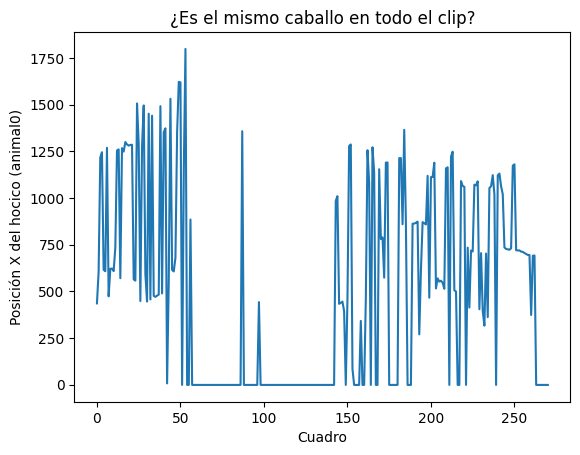

In [10]:
import matplotlib.pyplot as plt

df = pd.read_hdf(f'{base}/resultados/prueba3_gulfstream_adapt/gulfstream_clip_superanimal_quadruped_hrnet_w32_fasterrcnn_resnet50_fpn_v2.h5')
x_nose = df.xs(('animal0', 'nose', 'x'), level=('individuals', 'bodyparts', 'coords'), axis=1)

plt.plot(x_nose)
plt.xlabel('Cuadro')
plt.ylabel('Posición X del hocico (animal0)')
plt.title('¿Es el mismo caballo en todo el clip?')
plt.show()

### Resultado: el supuesto es falso

El gráfico muestra saltos bruscos y constantes en la posición X a lo
largo del clip, en vez de una trayectoria continua y suave (la esperable
si fuera un único caballo en movimiento). Esto confirma que la etiqueta
`animal0` **no mantiene identidad consistente entre cuadros**: el
detector (Faster R-CNN) procesa cada cuadro de forma independiente, sin
ningún mecanismo de seguimiento (tracking), y el número asignado a cada
individuo depende del orden interno de detección en ese cuadro puntual,
no de qué caballo es.

### Consecuencia

La comparación de porcentaje de keypoints bien detectados calculada en
la sección anterior (Gulfstream 22.0% → 34.4%, Belmont 35.7% → 57.5%)
**no es válida tal como fue calculada**, ya que mezcla datos de varios
caballos distintos bajo una misma etiqueta, cuadro a cuadro. Los
números en sí no se descartan como dato crudo, pero la interpretación
("mejora del jitter del adapt") no puede sostenerse sin antes resolver
la identidad de cada individuo.

### Próximo paso

Esto confirma, con evidencia concreta, la necesidad ya prevista en el
Alcance de un módulo de tracking (seguimiento de identidad entre
cuadros) antes de poder calcular cualquier métrica por caballo
individual de forma confiable: longitud de zancada, ángulos
articulares, simetría bilateral, y también estas comparaciones de
estabilidad de detección. Sin tracking, cualquier análisis por
individuo corre el riesgo de mezclar datos de caballos distintos sin
que sea evidente a simple vista (el error solo se hizo visible al
graficar la trayectoria).

Herramienta prevista para esto: YOLOv8 (ya contemplado en el stack
original del proyecto), a implementar en la próxima etapa del pipeline.

### Confirmación adicional: comparación entre animal0 y animal1

Antes de concluir que el problema era mezcla de identidad, se consideró
una explicación alternativa: que los saltos se debieran a cortes de
cámara dentro del propio clip (el tramo analizado sí contiene algunos
cambios de plano), y no a un error del pipeline.

Para distinguir entre ambas causas, se graficó la posición X del hocico
de `animal0` junto con la de `animal1`, superpuestas.

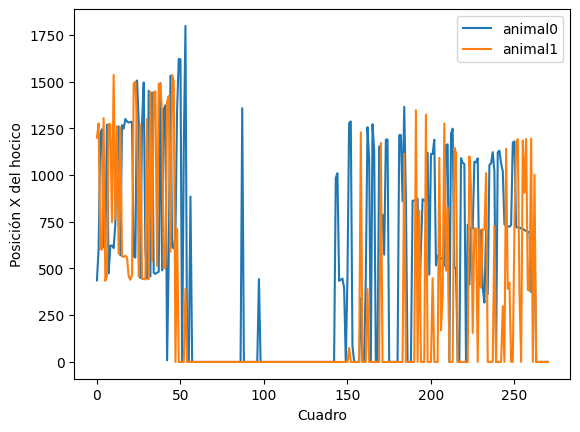

In [11]:
x_nose_0 = df.xs(('animal0', 'nose', 'x'), level=('individuals', 'bodyparts', 'coords'), axis=1)
x_nose_1 = df.xs(('animal1', 'nose', 'x'), level=('individuals', 'bodyparts', 'coords'), axis=1)

plt.plot(x_nose_0, label='animal0')
plt.plot(x_nose_1, label='animal1')
plt.xlabel('Cuadro')
plt.ylabel('Posición X del hocico')
plt.legend()
plt.show()

**Resultado**: las dos líneas zigzaguean de forma prácticamente calcada
entre sí durante todo el clip, no solo en los momentos puntuales
esperables de un corte de cámara. Un corte real produciría saltos
aislados y sincronizados en unos pocos cuadros puntuales, con tramos
suaves entre medio; lo observado es, en cambio, un zigzag constante
cuadro a cuadro a lo largo de todo el clip, con ambas líneas
intercambiando valores entre sí de forma sistemática.

Esto descarta los cortes de cámara como causa principal (aunque sí
están presentes en el clip y pueden contribuir a parte del ruido) y
confirma que el detector reordena la asignación de IDs (`animal0`,
`animal1`, ...) de forma inconsistente entre cuadros consecutivos, sin
mecanismo de seguimiento de identidad. Se reafirma la necesidad de un
módulo de tracking (ver conclusión y próximo paso más arriba).